#  " Predicting Airline Passenger Satisfaction Using Machine Learning: A Data-                      Driven Approach to Enhancing Customer Experience “


In [4]:
# IMPORT LIBRARIES 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

print("Libraries imported successfully!")

Libraries imported successfully!


In [5]:
df = pd.read_csv("C:\\Users\\Supriya\\Desktop\\placement_project\\data\\DS-DATA.csv", low_memory=False)# Fix mixed datatype warning in Flight Distance
df["Flight Distance"] = pd.to_numeric(
    df["Flight Distance"],
    errors="coerce")# convert Flight Distance to number; non-convertible → NaN
print("uploaded dataset successfully!")

uploaded dataset successfully!


In [6]:
print("\nShape:", df.shape)# (rows, columns)


Shape: (129880, 24)


In [7]:
print(df.head())# first 5 rows

   ID  Gender  Age Customer Type Type of Travel     Class  Flight Distance  \
0   1    Male   48    First-time       Business  Business            821.0   
1   2  Female   35     Returning       Business  Business            821.0   
2   3    Male   41     Returning       Business  Business            853.0   
3   4    Male   50     Returning       Business  Business           1905.0   
4   5  Female   49     Returning       Business  Business           3470.0   

   Departure Delay  Arrival Delay  Departure and Arrival Time Convenience  \
0                2            5.0                                       3   
1               26           39.0                                       2   
2                0            0.0                                       4   
3                0            0.0                                       2   
4                0            1.0                                       3   

   ...  On-board Service  Seat Comfort  Leg Room Service  Cleanlines

In [8]:
print("\n Info:"); print(df.info()) # column names, types, non-null counts


 Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 24 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   ID                                      129880 non-null  int64  
 1   Gender                                  129880 non-null  object 
 2   Age                                     129880 non-null  int64  
 3   Customer Type                           129880 non-null  object 
 4   Type of Travel                          129880 non-null  object 
 5   Class                                   129880 non-null  object 
 6   Flight Distance                         129877 non-null  float64
 7   Departure Delay                         129880 non-null  int64  
 8   Arrival Delay                           129487 non-null  float64
 9   Departure and Arrival Time Convenience  129880 non-null  int64  
 10  Ease of Online Booking              

In [9]:
print("\n Missing Values:\n", df.isnull().sum())# missing count per column


 Missing Values:
 ID                                          0
Gender                                      0
Age                                         0
Customer Type                               0
Type of Travel                              0
Class                                       0
Flight Distance                             3
Departure Delay                             0
Arrival Delay                             393
Departure and Arrival Time Convenience      0
Ease of Online Booking                      0
Check-in Service                            0
Online Boarding                             0
Gate Location                               0
On-board Service                            0
Seat Comfort                                0
Leg Room Service                            0
Cleanliness                                 0
Food and Drink                              0
In-flight Service                           0
In-flight Wifi Service                      0
In-flight Enter

In [10]:
print("\n Summary:\n", df.describe())# min, max, mean per column


 Summary:
                   ID            Age  Flight Distance  Departure Delay  \
count  129880.000000  129880.000000    129877.000000    129880.000000   
mean    64940.500000      39.427957      1190.312249        14.713713   
std     37493.270818      15.119360       997.433388        38.071126   
min         1.000000       7.000000        31.000000         0.000000   
25%     32470.750000      27.000000       414.000000         0.000000   
50%     64940.500000      40.000000       844.000000         0.000000   
75%     97410.250000      51.000000      1744.000000        12.000000   
max    129880.000000      85.000000      4983.000000      1592.000000   

       Arrival Delay  Departure and Arrival Time Convenience  \
count  129487.000000                           129880.000000   
mean       15.091129                                3.057599   
std        38.465650                                1.526741   
min         0.000000                                0.000000   
25%       

In [11]:
# TARGET VARIABLE CHECK
print("\n Satisfaction Count:\n", df["Satisfaction"].value_counts())# count of Satisfied vs Not Satisfied


 Satisfaction Count:
 Satisfaction
Neutral or Dissatisfied    73452
Satisfied                  56428
Name: count, dtype: int64


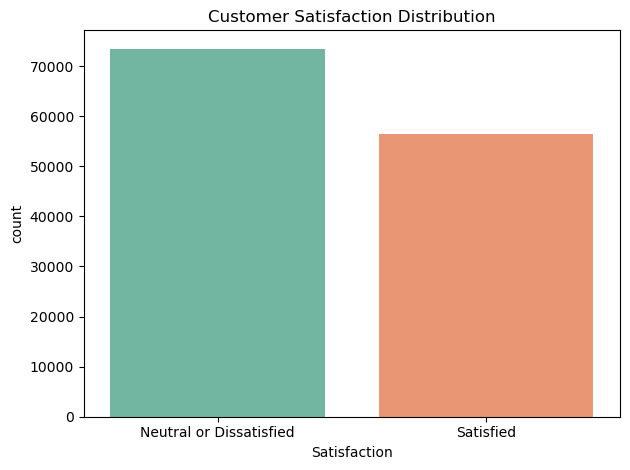

In [12]:
# Plot satisfaction distribution
sns.countplot(x="Satisfaction", data=df, palette="Set2")# bar chart
plt.title("Customer Satisfaction Distribution")
plt.tight_layout(); plt.show()

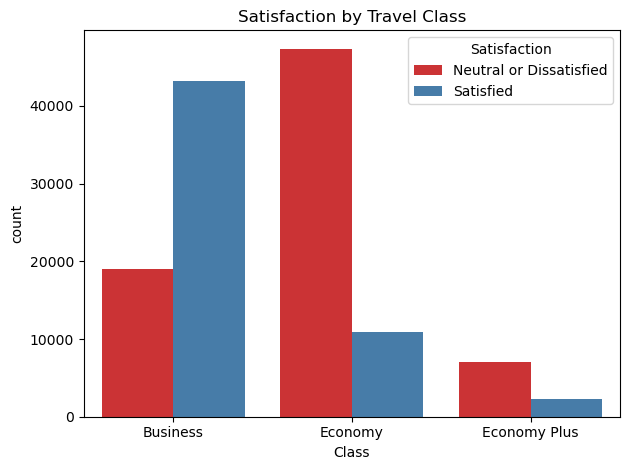

In [13]:
# EDA CHARTS To Find Pain Points

# Chart 1: By Class
sns.countplot(x="Class", hue="Satisfaction", data=df, palette="Set1")
plt.title("Satisfaction by Travel Class")
plt.tight_layout(); plt.show()

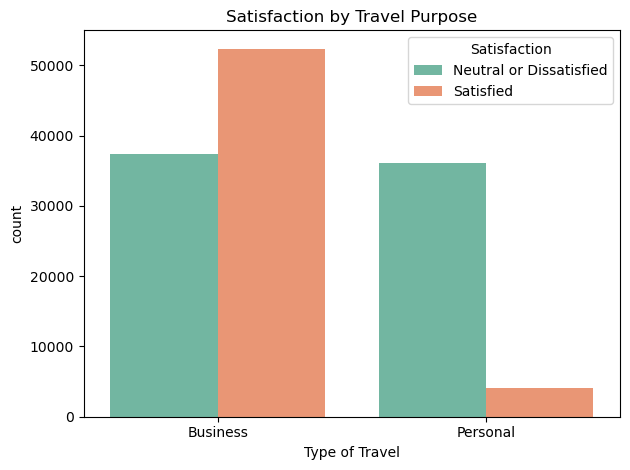

In [14]:
# Chart 2: By Travel Type
sns.countplot(x="Type of Travel", hue="Satisfaction", data=df, palette="Set2")
plt.title("Satisfaction by Travel Purpose")
plt.tight_layout(); plt.show()

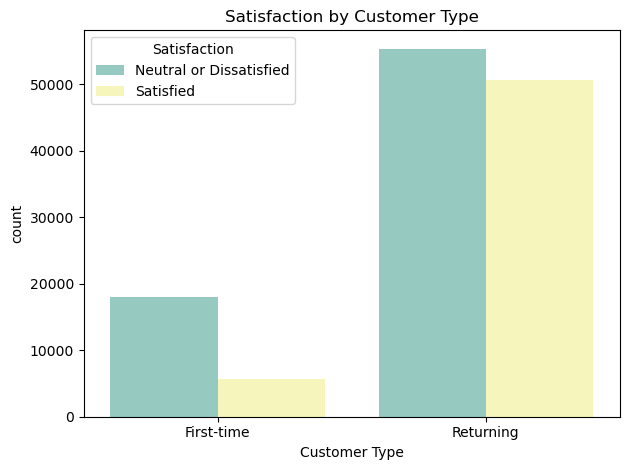

In [15]:
# Chart 3: By Customer Type
sns.countplot(x="Customer Type", hue="Satisfaction", data=df, palette="Set3")
plt.title("Satisfaction by Customer Type")
plt.tight_layout(); plt.show()

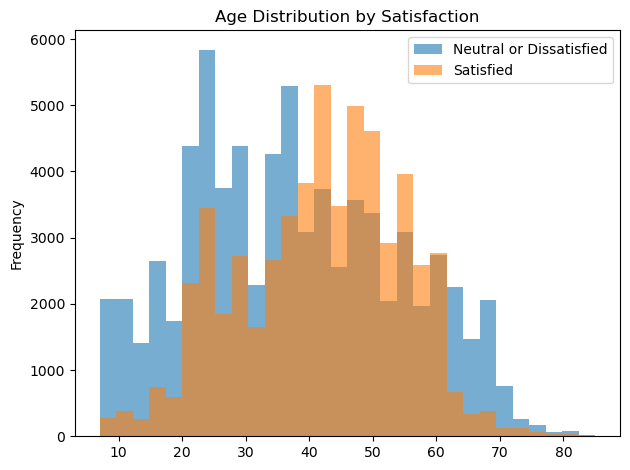

In [16]:
# Chart 4: Age Distribution
df.groupby("Satisfaction")["Age"].plot(kind="hist", alpha=0.6, bins=30, legend=True)
plt.title("Age Distribution by Satisfaction")
plt.tight_layout(); plt.show()

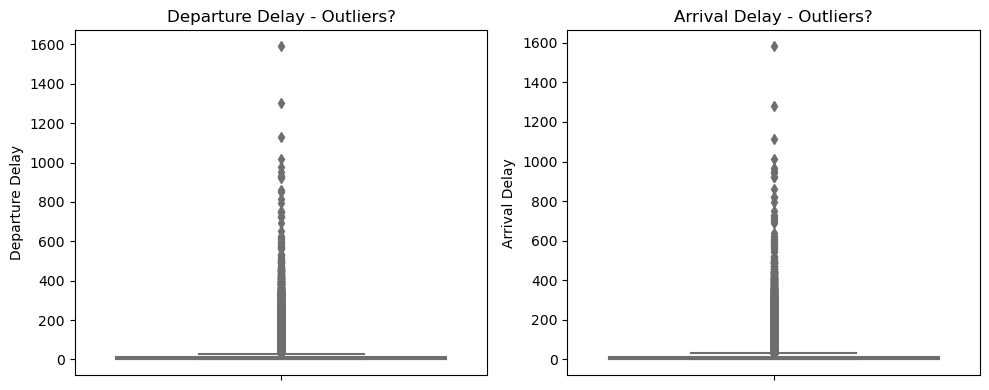

In [17]:
# Chart 5: Outlier Check (Box Plots for Delays)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(y="Departure Delay", data=df, ax=axes[0], color="skyblue")
sns.boxplot(y="Arrival Delay",   data=df, ax=axes[1], color="salmon")
axes[0].set_title("Departure Delay - Outliers?")# dots above box = extreme outliers
axes[1].set_title("Arrival Delay - Outliers?")
plt.tight_layout(); plt.show()

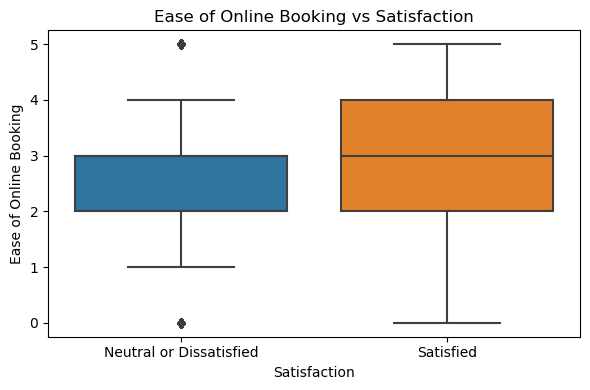

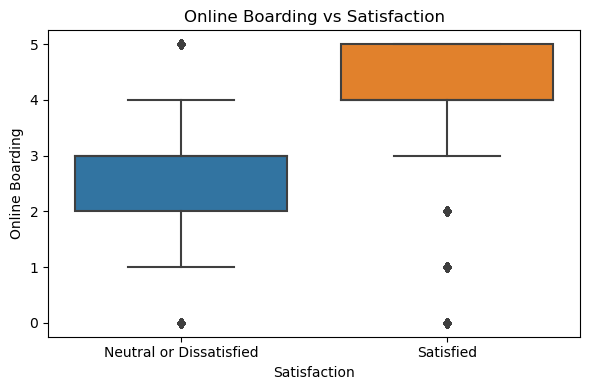

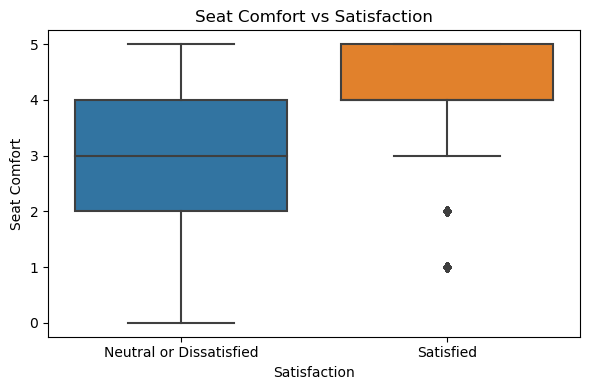

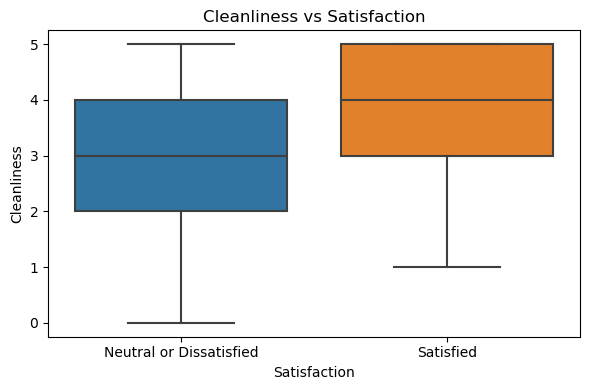

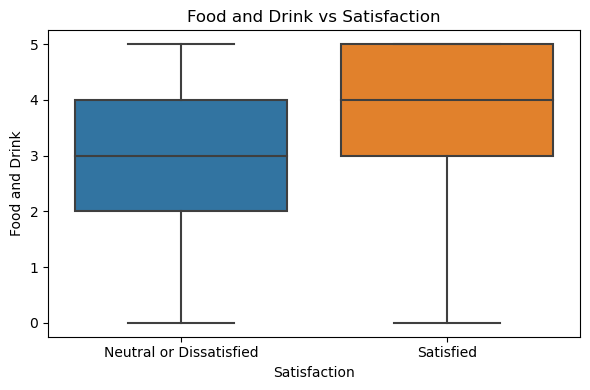

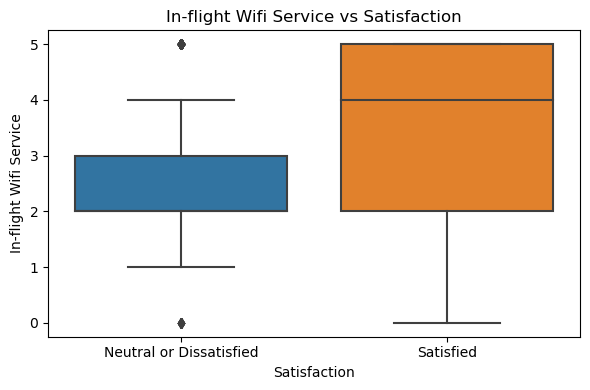

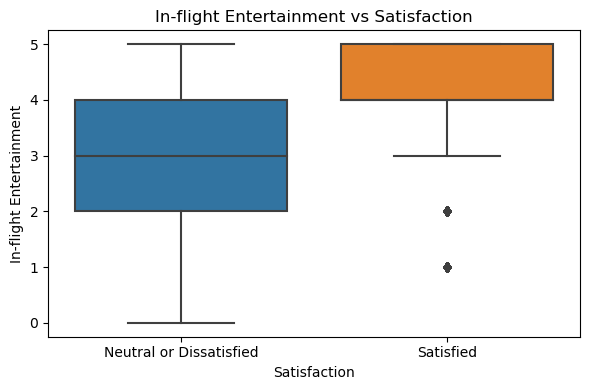

In [18]:
# Service-Rating Analysis
service_cols = [
    "Ease of Online Booking",
    "Online Boarding",
    "Seat Comfort",
    "Cleanliness",
    "Food and Drink",
    "In-flight Wifi Service",
    "In-flight Entertainment"
]
for col in service_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x="Satisfaction", y=col, data=df)
    plt.title(f"{col} vs Satisfaction")
    plt.tight_layout()
    plt.show()

In [19]:
for col in df.select_dtypes(include=np.number).columns:
    df[col] = df[col].fillna(df[col].median())
print("\n Missing values filled with median!") # fill empty cells with column median


 Missing values filled with median!


In [20]:
# CAP OUTLIERS IN DELAY COLUMNS 
# Cap extreme delay values at 99th percentile
for col in ["Departure Delay", "Arrival Delay"]:
    if col in df.columns:
        cap = df[col].quantile(0.99)# 99th percentile = max allowed value
        df[col] = df[col].clip(upper=cap)# replace anything above cap with cap
print(" Outliers capped at 99th percentile!")

 Outliers capped at 99th percentile!


In [21]:
# DROP ID COLUMN
if "ID" in df.columns:
    df.drop("ID", axis=1, inplace=True) # ID has no predictive value → remove
    print(" ID column dropped!")

 ID column dropped!


In [22]:
# ENCODE CATEGORICAL COLUMNS (Text → Numbers)
label_encoders = {}  # store encoders in case we need to reverse later
for col in df.select_dtypes(include="object").columns:
    if col != "Satisfaction":
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        label_encoders[col] = le
print(" Categorical columns encoded!")

 Categorical columns encoded!


In [23]:
# ENCODE TARGET COLUMN
target_encoder = LabelEncoder()
df["Satisfaction"] = target_encoder.fit_transform(df["Satisfaction"])# Neutral or Dissatisfied → 0 | Satisfied → 1
print("\n Target Encoding:", dict(zip(target_encoder.classes_,
                                        target_encoder.transform(target_encoder.classes_))))


 Target Encoding: {'Neutral or Dissatisfied': 0, 'Satisfied': 1}


In [24]:
# CLASS IMBALANCE CHECK 
class_counts = df["Satisfaction"].value_counts()
min_pct = class_counts.min() / len(df) * 100 # minority class %
use_class_weight = min_pct < 35 # True = imbalanced; apply correction
if use_class_weight:
    print("  Imbalanced data! Applying class_weight='balanced'")
else:
    print(" Data is balanced!")
scale_pos_weight = (
    class_counts.max() / class_counts.min()
    if use_class_weight
    else 1
)# ratio used by XGBoost to correct for imbalance

 Data is balanced!


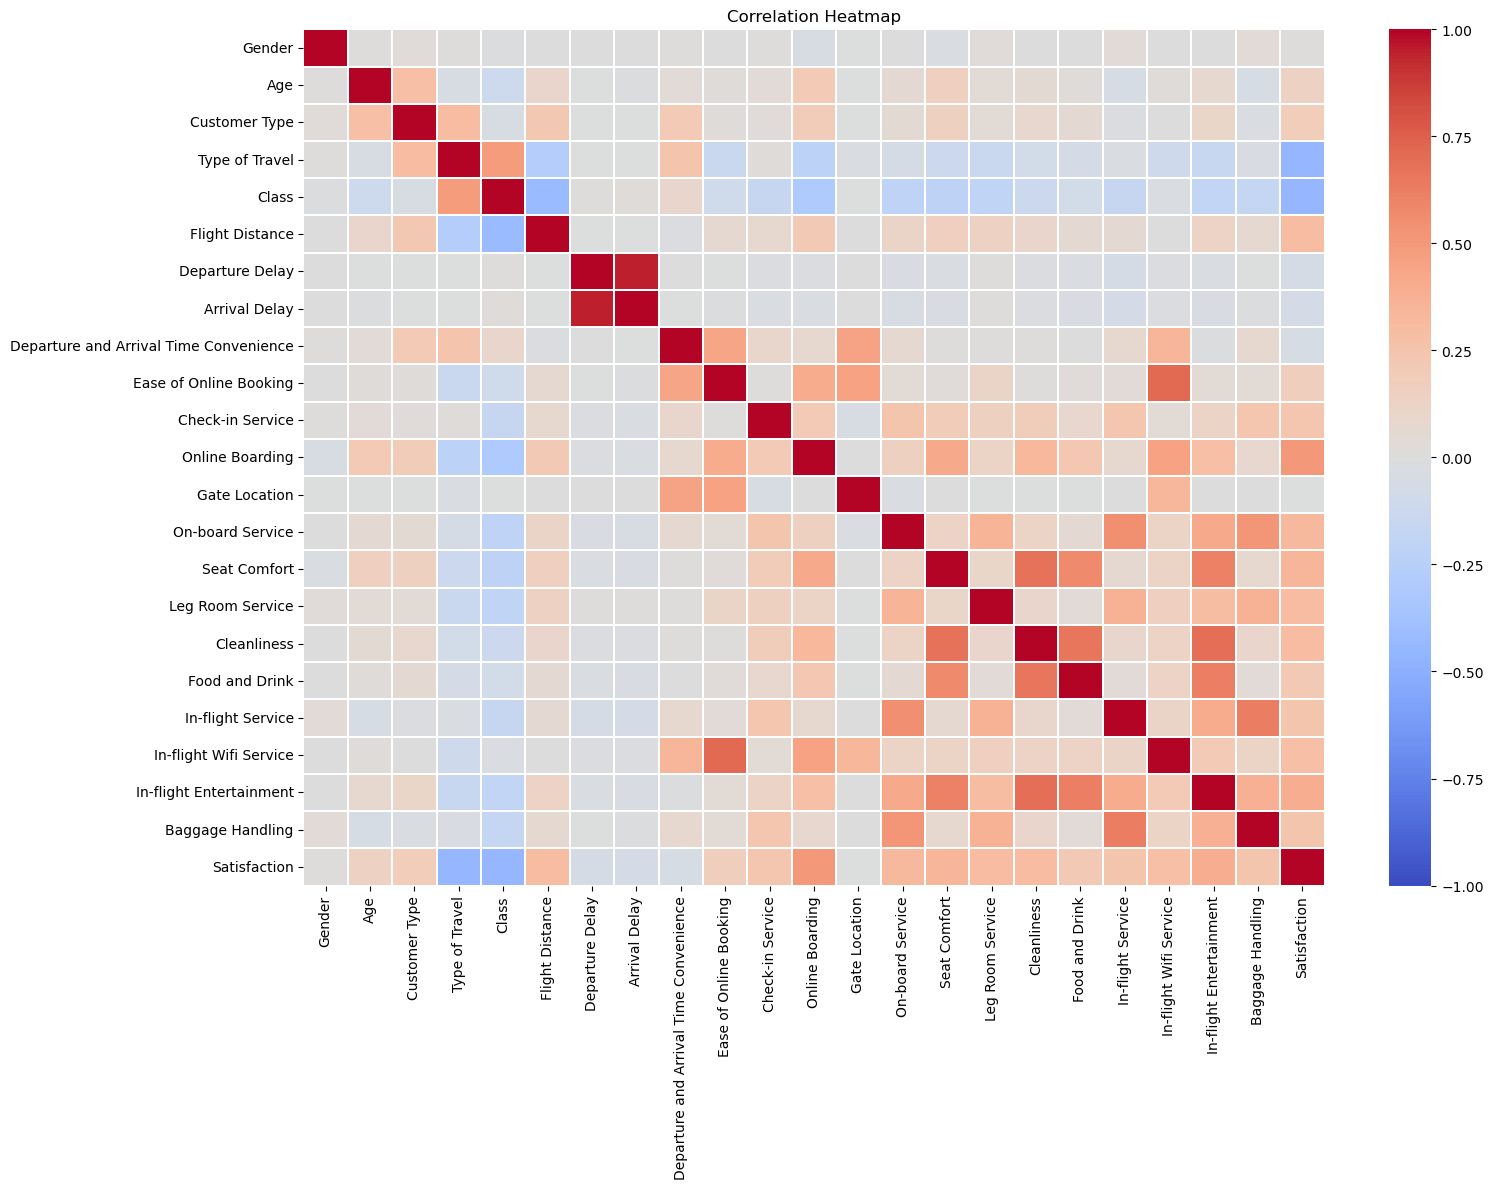

In [25]:
# CORRELATION HEATMAP
plt.figure(figsize=(16, 12))
sns.heatmap(df.select_dtypes(include=np.number).corr(),cmap="coolwarm",linewidths=0.3,vmin=-1,vmax=1)
plt.title("Correlation Heatmap")# correlation table of all numeric columns
plt.tight_layout(); plt.show()# blue = negative, red = positive

In [26]:
# SPLIT DATA (Features & Target, Train/Test) 
X = df.drop("Satisfaction", axis=1)   # Input features all columns except target = features
y = df["Satisfaction"]                 # Target column to predict

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
) 
# 80% train, 20% test
# fixed seed → same split every run
# keep same class ratio in both sets
print(f"\n Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")


 Train: 103904 rows | Test: 25976 rows


In [27]:
# FEATURE SCALING (Required for Logistic Regression) 
# Scale ONLY on train data → apply to test so it prevents data leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)# learn scale from train, apply    
X_test_scaled  = scaler.transform(X_test) # apply SAME scale to test (no leakage)
print("Scaling done!")

Scaling done!


In [28]:
# TRAIN 4 MODELS & COMPARE 
cw = "balanced" if use_class_weight else None # class weight setting for LR and RF
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight=cw, random_state=42),# draws a decision boundary and needs scaled data
    "Decision Tree"      : DecisionTreeClassifier(random_state=42),# yes/no flowchart
    "Random Forest"      : RandomForestClassifier(n_estimators=100, class_weight=cw, random_state=42),# 100 trees vote together
    "XGBoost"            : XGBClassifier(eval_metric="logloss",random_state=42,verbosity=0,scale_pos_weight=scale_pos_weight)# builds trees sequentially, each fixing previous errors
}
results        = []
best_accuracy  = 0
best_model     = None
best_model_name= ""
print("\n Training Models...\n" + "-"*45)

for name, model in models.items():
    # LR uses scaled data and tree models use original
    Xtr = X_train_scaled if name == "Logistic Regression" else X_train
    Xte = X_test_scaled  if name == "Logistic Regression" else X_test

    model.fit(Xtr, y_train)#train
    y_pred   = model.predict(Xte)# predict on unseen test data
    accuracy = accuracy_score(y_test, y_pred) # % correct

    # 5-fold Cross Validation → more reliable than single split
    # 5-fold CV → split train into 5, rotate through for stable accuracy
    cv = cross_val_score(model, Xtr, y_train, cv=5, scoring="accuracy")
    results.append([name, round(accuracy*100,2), round(cv.mean()*100,2), round(cv.std()*100,2)])

    print(f"  {name}")
    print(f"    Test Accuracy : {round(accuracy*100,2)}%")
    print(f"    CV Accuracy   : {round(cv.mean()*100,2)}% ± {round(cv.std()*100,2)}%\n")

    if accuracy > best_accuracy:
        best_accuracy, best_model, best_model_name = accuracy, model, name

print(f" Best Model : {best_model_name}  ({round(best_accuracy*100,2)}%)")



 Training Models...
---------------------------------------------
  Logistic Regression
    Test Accuracy : 87.76%
    CV Accuracy   : 87.35% ± 0.12%

  Decision Tree
    Test Accuracy : 94.96%
    CV Accuracy   : 94.62% ± 0.21%

  Random Forest
    Test Accuracy : 96.33%
    CV Accuracy   : 96.22% ± 0.13%

  XGBoost
    Test Accuracy : 96.61%
    CV Accuracy   : 96.34% ± 0.1%

 Best Model : XGBoost  (96.61%)


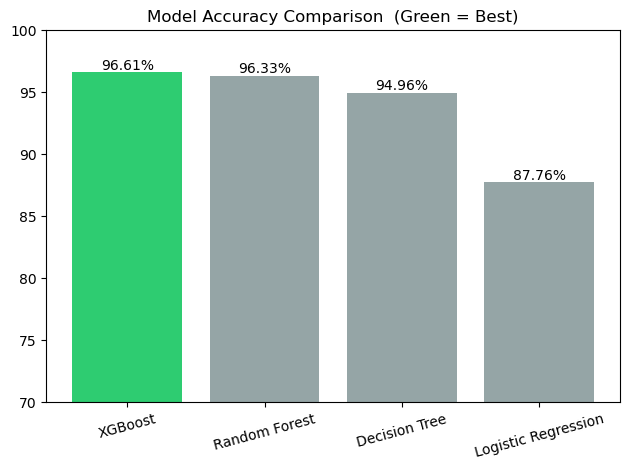

In [29]:
# MODEL COMPARISON CHART 
comp_df = pd.DataFrame(results, columns=["Model", "Test Acc %", "CV Mean %", "CV Std %"])
comp_df = comp_df.sort_values("Test Acc %", ascending=False)# highest first
colors = ["#2ecc71" if n == best_model_name else "#95a5a6" for n in comp_df["Model"]]
bars = plt.bar(comp_df["Model"], comp_df["Test Acc %"], color=colors)
plt.title("Model Accuracy Comparison  (Green = Best)")
plt.ylim(70, 100); plt.xticks(rotation=15)# start y-axis at 70 so differences are visible
for b, v in zip(bars, comp_df["Test Acc %"]):
    plt.text(b.get_x()+b.get_width()/2, b.get_height()+0.2, f"{v}%", ha="center", fontsize=10)
plt.tight_layout(); plt.show()

In [30]:
# EVALUATE BEST MODEL 
Xte_best = X_test_scaled if best_model_name == "Logistic Regression" else X_test
y_pred_best = best_model.predict(Xte_best)

# Classification Report (Precision, Recall, F1)
print("\n Classification Report:")
print(classification_report(y_test, y_pred_best, target_names=target_encoder.classes_))
# Precision = how many predicted positives were right
# Recall    = how many actual positives were caught
# F1        = balance of precision & recall


 Classification Report:
                         precision    recall  f1-score   support

Neutral or Dissatisfied       0.96      0.98      0.97     14690
              Satisfied       0.97      0.95      0.96     11286

               accuracy                           0.97     25976
              macro avg       0.97      0.96      0.97     25976
           weighted avg       0.97      0.97      0.97     25976



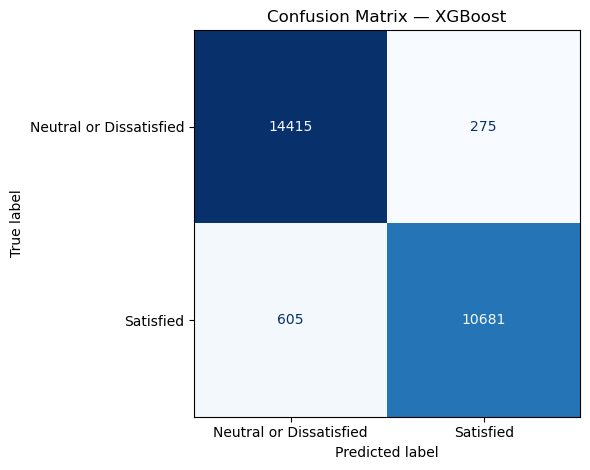

In [31]:
# Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred_best)
ConfusionMatrixDisplay(cm, display_labels=target_encoder.classes_).plot(cmap="Blues", colorbar=False)
plt.title(f"Confusion Matrix — {best_model_name}")
plt.tight_layout(); plt.show()
# [TN, FP]
# [FN, TP]  → correct predictions on diagonal


 Top 10 Features Driving Satisfaction:


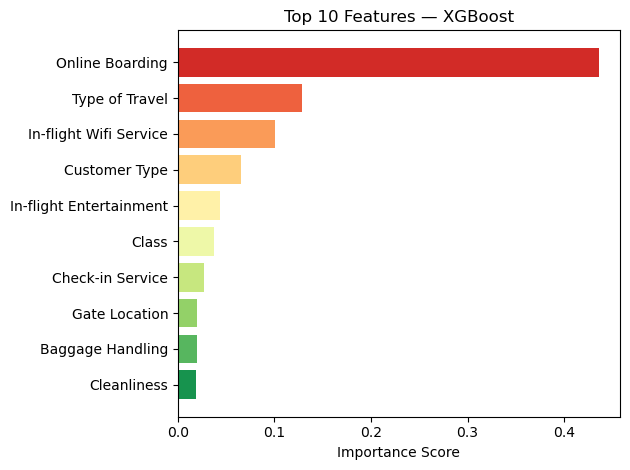

                Feature  Importance
        Online Boarding    0.436086
         Type of Travel    0.128439
 In-flight Wifi Service    0.100874
          Customer Type    0.065632
In-flight Entertainment    0.043738
                  Class    0.037856
       Check-in Service    0.026706
          Gate Location    0.019539
       Baggage Handling    0.019508
            Cleanliness    0.019063


In [32]:
# FEATURE IMPORTANCE 
print("\n Top 10 Features Driving Satisfaction:")
# feature_importances_ → how much each column contributed to predictions
if best_model_name != "Logistic Regression":
    imp_df = pd.DataFrame({"Feature": X.columns, "Importance": best_model.feature_importances_})
    imp_df = imp_df.sort_values("Importance", ascending=False).head(10)
    colors = sns.color_palette("RdYlGn", 10)[::-1] # green = most important
    plt.barh(imp_df["Feature"][::-1], imp_df["Importance"][::-1], color=colors)
else:
    imp_df = pd.DataFrame({"Feature": X.columns, "Importance": np.abs(best_model.coef_[0])})
     # coef_ absolute value → feature influence for Logistic Regression
    imp_df = imp_df.sort_values("Importance", ascending=False).head(10)
    plt.barh(imp_df["Feature"][::-1], imp_df["Importance"][::-1], color="steelblue")

plt.xlabel("Importance Score")
plt.title(f"Top 10 Features — {best_model_name}")
plt.tight_layout(); plt.show()
print(imp_df.to_string(index=False))

In [33]:
print("\n PAIN POINT ANALYSIS")
rating_cols = [
    "Ease of Online Booking",
    "Online Boarding",
    "Seat Comfort",
    "Cleanliness",
    "Food and Drink",
    "In-flight Wifi Service",
    "In-flight Entertainment"
]
pain_points = (
    df.groupby("Satisfaction")[rating_cols]
      .mean()
      .round(2)
)# big gap between satisfied (1) and dissatisfied (0) = key pain point
print(pain_points)


 PAIN POINT ANALYSIS
              Ease of Online Booking  Online Boarding  Seat Comfort  \
Satisfaction                                                          
0                               2.55             2.66          3.04   
1                               3.03             4.03          3.97   

              Cleanliness  Food and Drink  In-flight Wifi Service  \
Satisfaction                                                        
0                    2.93            2.96                    2.40   
1                    3.75            3.53                    3.16   

              In-flight Entertainment  
Satisfaction                           
0                                2.89  
1                                3.96  


In [34]:
# BUSINESS INSIGHTS 
print("""
              BUSINESS INSIGHTS
==================================================
TOP FACTORS AFFECTING SATISFACTION (From Our Data):
  1. Online Boarding (43.6%)   → Improve the boarding app experience
  2. Type of Travel  (12.8%)   → Business travelers need priority service
  3. In-flight Wifi  (10.1%)   → Upgrade in-flight connectivity
  4. Customer Type   (6.6%)    → Loyalty rewards for returning customers
  5. In-flight Entertainment (4.4%) → Better content & streaming options
""")


              BUSINESS INSIGHTS
TOP FACTORS AFFECTING SATISFACTION (From Our Data):
  1. Online Boarding (43.6%)   → Improve the boarding app experience
  2. Type of Travel  (12.8%)   → Business travelers need priority service
  3. In-flight Wifi  (10.1%)   → Upgrade in-flight connectivity
  4. Customer Type   (6.6%)    → Loyalty rewards for returning customers
  5. In-flight Entertainment (4.4%) → Better content & streaming options



In [36]:
#  PREDICT ALL + SEGMENT CUSTOMERS
Xa  = scaler.transform(X) if best_model_name == "Logistic Regression" else X # scale all rows if LR, otherwise use as-is
all_preds  = target_encoder.inverse_transform(best_model.predict(Xa))# predict for all 129,880 passengers → convert 0/1 back to text labels
all_probas = best_model.predict_proba(Xa)[:, 1] * 100  # Satisfaction probability % of being Satisfied for each passenger
def segment(prob):
    if prob >= 80: return "Highly Satisfied"
    elif prob >= 50: return "Neutral"
    else: return "Dissatisfied(at risk)"
# bucket each passenger based on their satisfaction probability
output_df = pd.read_csv("C:\\Users\\Supriya\\Desktop\\placement_project\\data\\DS-DATA.csv",low_memory=False)# reload original (readable) data
output_df["Predicted_Satisfaction"]    = all_preds
output_df["Satisfaction_Probability%"] = all_probas.round(2)
output_df["Customer_Segment"]          = [segment(p) for p in all_probas]
print(" Sample Output:")
print(output_df[["Predicted_Satisfaction","Satisfaction_Probability%","Customer_Segment"]].head(5))

 Sample Output:
    Predicted_Satisfaction  Satisfaction_Probability%       Customer_Segment
0  Neutral or Dissatisfied                  17.290001  Dissatisfied(at risk)
1                Satisfied                  99.989998       Highly Satisfied
2                Satisfied                  99.949997       Highly Satisfied
3                Satisfied                  99.989998       Highly Satisfied
4                Satisfied                  99.970001       Highly Satisfied


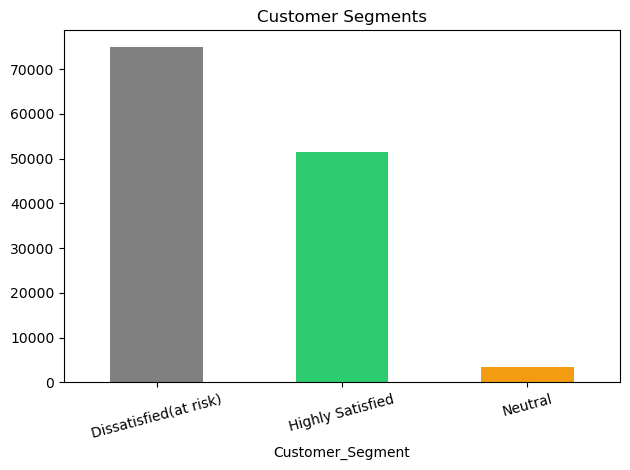

In [37]:
# SEGMENTATION CHART
seg_colors = {"Highly Satisfied":"#2ecc71","Neutral":"#f39c12","Dissatisfied":"#e74c3c"}
seg_counts  = output_df["Customer_Segment"].value_counts()
seg_counts.plot(kind="bar", color=[seg_colors.get(s,"gray") for s in seg_counts.index])
plt.title("Customer Segments"); plt.xticks(rotation=15)
plt.tight_layout(); plt.show()

In [38]:
print("\nTop 5 At-Risk Customers")
print(
    output_df[
        ["ID",
         "Satisfaction_Probability%",
         "Customer_Segment"]
    ]
    .sort_values(
        by="Satisfaction_Probability%"
    )
    .head()
)


Top 5 At-Risk Customers
            ID  Satisfaction_Probability%       Customer_Segment
61755    61756                        0.0  Dissatisfied(at risk)
123604  123605                        0.0  Dissatisfied(at risk)
23218    23219                        0.0  Dissatisfied(at risk)
45383    45384                        0.0  Dissatisfied(at risk)
23217    23218                        0.0  Dissatisfied(at risk)


In [39]:
#  SAVE OUTPUT FILE
output_df.to_csv("Final_Airline_Customer_Report.csv", index=False)
print(" Report saved:  Final_Airline_Customer_Report.csv")

 Report saved:  Final_Airline_Customer_Report.csv


In [40]:
# FINAL SUMMARY 
print(f"""
 Best Model    : {best_model_name}
 Test Accuracy : {round(best_accuracy*100,2)}%
""")


 Best Model    : XGBoost
 Test Accuracy : 96.61%



In [41]:
import os

os.makedirs("output", exist_ok=True)

output_df.to_csv(
    "output/Airline_Satisfaction_Output.csv",
    index=False
)

print("Output file generated successfully!")

Output file generated successfully!
